# 02 · 단면 제원 — 총단면과 환산단면

`ConcreteSection` 객체를 만들면 총단면 제원이 자동으로 계산된다.
원 문서의 `area_properties.ipynb` 에 대응한다.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

# 한글 글꼴이 없는 환경에서도 그림이 깨지지 않도록 축 라벨은 ASCII 로 둔다
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 96

In [2]:
from concreteproperties import ConcreteSection
from sectionproperties.pre.library import concrete_rectangular_section

from concreteproperties_kds import KDS


def beam_section(fck=27, fy=400):
    """400 x 600 보 단면 (상부 2-D16, 하부 4-D22, 피복 50 mm)."""
    kds = KDS(column_type="tie")
    conc = kds.create_concrete_material(compressive_strength=fck)
    steel = kds.create_steel_material(yield_strength=fy)

    geom = concrete_rectangular_section(
        d=600, b=400,
        dia_top=16, area_top=198.6, n_top=2, c_top=50,
        dia_bot=22, area_bot=387.1, n_bot=4, c_bot=50,
        n_circle=16, conc_mat=conc, steel_mat=steel,
    )
    conc_sec = ConcreteSection(geom)
    kds.assign_concrete_section(conc_sec)
    return kds, conc_sec


def column_section(fck=27, fy=400, column_type="tie"):
    """500 x 500 기둥 단면 (8-D22, 피복 50 mm)."""
    kds = KDS(column_type=column_type)
    conc = kds.create_concrete_material(compressive_strength=fck)
    steel = kds.create_steel_material(yield_strength=fy)

    geom = concrete_rectangular_section(
        d=500, b=500,
        dia_top=22, area_top=387.1, n_top=3, c_top=50,
        dia_bot=22, area_bot=387.1, n_bot=3, c_bot=50,
        dia_side=22, area_side=387.1, n_side=1, c_side=50,
        n_circle=16, conc_mat=conc, steel_mat=steel,
    )
    conc_sec = ConcreteSection(geom)
    kds.assign_concrete_section(conc_sec)
    return kds, conc_sec

/tmp/claude-0/-home-user-wkclauderepositoty/78f995f2-8acb-52ee-a7a0-dbb2b3510f36/scratchpad/venv312/lib/python3.12/site-packages/concreteproperties/post.py:90: UserWarning: Glyph 53080 (\N{HANGUL SYLLABLE KON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/claude-0/-home-user-wkclauderepositoty/78f995f2-8acb-52ee-a7a0-dbb2b3510f36/scratchpad/venv312/lib/python3.12/site-packages/concreteproperties/post.py:90: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/claude-0/-home-user-wkclauderepositoty/78f995f2-8acb-52ee-a7a0-dbb2b3510f36/scratchpad/venv312/lib/python3.12/site-packages/concreteproperties/post.py:90: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/claude-0/-home-user-wkclauderepositoty/78f995f2-8acb-52ee-a7a0-dbb2b3510f36/scratchpad/venv312/lib/python3.12/site-packages/concreteproperties/post.py:90: UserWarning: Glyph 53944 (\N{HANGUL SYLLABL

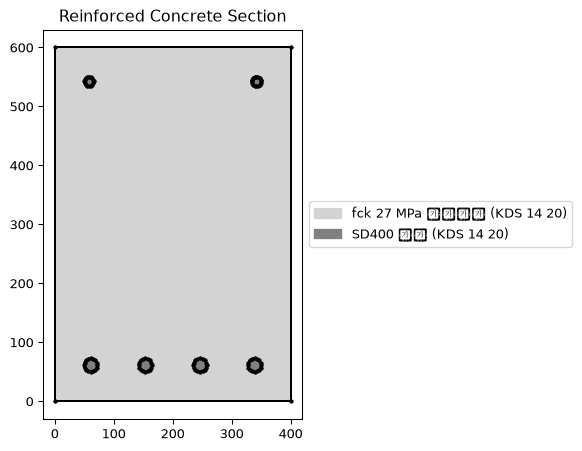

<Axes: title={'center': 'Reinforced Concrete Section'}>

In [3]:
kds, conc_sec = beam_section()
conc_sec.plot_section()

## 총단면 제원

`GrossProperties` 의 단면2차모멘트는 탄성계수가 곱해진 **휨강성** ($EI$)
이다. 순수한 $I$ 가 필요하면 환산단면 제원을 쓴다.

In [4]:
gross = kds.get_gross_properties()
gross.print_results()

         Gross Concrete Section Properties          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property                  ┃                Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ Total Area                │    240.0 x 10^3 mm^2 │
│ Concrete Area             │    238.1 x 10^3 mm^2 │
│ Lumped Reinforcement Area │    1.946 x 10^3 mm^2 │
│ Axial Rigidity (EA)       │       6.746 x 10^9 N │
│ Mass (per unit length)    │  562.8 x 10^-3 kg/mm │
│ Perimeter                 │      2.000 x 10^3 mm │
├───────────────────────────┼──────────────────────┤
│ E.Qx                      │   1.976 x 10^12 N.mm │
│ E.Qy                      │   1.349 x 10^12 N.mm │
│ x-Centroid                │             200.0 mm │
│ y-Centroid                │             293.0 mm │
│ x-Centroid (Gross)        │             200.0 mm │
│ y-Centroid (Gross)        │             300.0 mm │
├───────────────────────────┼──────────────────────┤
│ E.Ixx_g                   │ 790.2 x 10^12 N.mm^2 │
│ E.Iyy_g                   │ 359.5 x 10^12 N.mm^2 │
│ E.Ixy_g                   │ 395.2 x 10^12 N.mm^2 │
│ E.Ixx_c                   │ 211.3 x 10^12 N.mm^2 │
│ E.Iyy_c                   │ 89.72 x 10^12 N.mm^2 │
│ E.Ixy_c                   │ 250.0 x 10^-3 N.mm^2 │
│ E.I11                     │ 211.3 x 10^12 N.mm^2 │
│ E.I22                     │ 89.72 x 10^12 N.mm^2 │
│ Principal Axis Angle      │           0.000 rads │
├───────────────────────────┼──────────────────────┤
│ E.Zxx+                    │    688.1 x 10^9 N.mm │
│ E.Zxx-                    │    721.2 x 10^9 N.mm │
│ E.Zyy+                    │    448.6 x 10^9 N.mm │
│ E.Zyy-                    │    448.6 x 10^9 N.mm │
│ E.Z11+                    │    688.1 x 10^9 N.mm │
│ E.Z11-                    │    721.2 x 10^9 N.mm │
│ E.Z22+                    │    448.6 x 10^9 N.mm │
│ E.Z22-                    │    448.6 x 10^9 N.mm │
├───────────────────────────┼──────────────────────┤
│ Ultimate Concrete Strain  │        3.300 x 10^-3 │
└───────────────────────────┴──────────────────────┘

## 콘크리트 환산단면 제원

In [5]:
conc = conc_sec.concrete_geometries[0].material

transformed = kds.get_transformed_gross_properties(
    elastic_modulus=conc.elastic_modulus
)
transformed.print_results()

   Transformed Gross Concrete    
       Section Properties        
┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Property ┃              Value ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ E_ref    │   26.70 x 10^3 MPa │
│ Area     │  252.6 x 10^3 mm^2 │
├──────────┼────────────────────┤
│ Qx       │  74.01 x 10^6 mm^3 │
│ Qy       │  50.53 x 10^6 mm^3 │
│ Ixx_g    │  29.60 x 10^9 mm^4 │
│ Iyy_g    │  13.47 x 10^9 mm^4 │
│ Ixy_g    │  14.80 x 10^9 mm^4 │
│ Ixx_c    │  7.913 x 10^9 mm^4 │
│ Iyy_c    │  3.360 x 10^9 mm^4 │
│ Ixy_c    │ 9.363 x 10^-6 mm^4 │
│ I11      │  7.913 x 10^9 mm^4 │
│ I22      │  3.360 x 10^9 mm^4 │
├──────────┼────────────────────┤
│ Zxx+     │  25.77 x 10^6 mm^3 │
│ Zxx-     │  27.01 x 10^6 mm^3 │
│ Zyy+     │  16.80 x 10^6 mm^3 │
│ Zyy-     │  16.80 x 10^6 mm^3 │
│ Z11+     │  25.77 x 10^6 mm^3 │
│ Z11-     │  27.01 x 10^6 mm^3 │
│ Z22+     │  16.80 x 10^6 mm^3 │
│ Z22-     │  16.80 x 10^6 mm^3 │
└──────────┴────────────────────┘

In [6]:
print(f"환산 도심축 단면2차모멘트  Ixx_c = {transformed.ixx_c:,.0f} mm^4")
print(f"총단면 (400x600) 기준       bh^3/12 = {400 * 600 ** 3 / 12:,.0f} mm^4")
print(f"비                                  = "
      f"{transformed.ixx_c / (400 * 600 ** 3 / 12):.4f}")

환산 도심축 단면2차모멘트  Ixx_c = 7,912,837,641 mm^4
총단면 (400x600) 기준       bh^3/12 = 7,200,000,000 mm^4
비                                  = 1.0990


철근이 환산되어 들어오므로 환산단면의 $I$ 가 콘크리트만의 $bh^3/12$ 보다
크다.